## NLLB-200-distilled-600M Training for Bidirectional Russian and Komi-Zyrian Translation

Installing libraries.

In [ ]:
!pip -q install -U transformers datasets accelerate evaluate sacrebleu peft bitsandbytes sentencepiece "protobuf<6"

Imports.

In [ ]:
import os
import re
import numpy as np
import torch
import evaluate

from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

os.environ["TOKENIZERS_PARALLELISM"] = "false"
set_seed(42)

A parallel Rus-Komi dataset with 50k rows. It is almost based on the website of the Komi administration and Komi media library.

In [ ]:
raw = load_dataset("Horeknad/komi-russian-parallel-corpora")
ds = raw["train"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
print(ds)

Dataset({
    features: ['Коми язык', 'Русский язык', 'Source Datasets'],
    num_rows: 50815
})


The first data example.

In [ ]:
print(ds[0])

{'Коми язык': 'Владимир Уйба выль коронавирус инфекция паськалӧмлы паныд удж нуӧдан республиканскӧй оперштаблӧн помшуӧмъяс да эпидемиякӧд йитчӧм серпас йылысь ', 'Русский язык': 'Владимир Уйба о решениях республиканского оперштаба по противодействию распространению новой коронавирусной инфекции и эпидситуации ', 'Source Datasets': 1}


99.6 percent of the data is shorter than 400 characters.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

komi_col = "Коми язык"
ru_col = "Русский язык"

def normalize_text(text):
    return " ".join(str(text).split())

komi_lens = pd.Series([len(normalize_text(x)) for x in ds[komi_col]])
ru_lens = pd.Series([len(normalize_text(x)) for x in ds[ru_col]])

percent_komi = (komi_lens.lt(400).sum() / len(komi_lens)) * 100
percent_ru = (ru_lens.lt(400).sum() / len(ru_lens)) * 100

percent_komi, percent_ru

(np.float64(99.60838335137264), np.float64(99.55131358850733))

The text-length distributions for both languages are approximately the same.

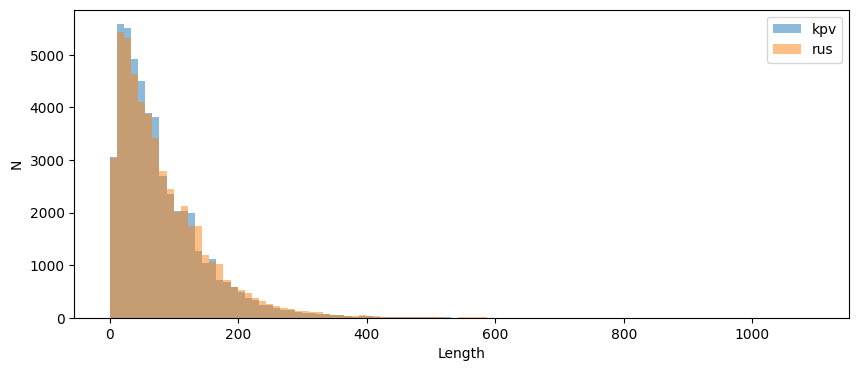

In [ ]:
bins = np.linspace(0, max(max(komi_lens), max(ru_lens)), 100)

plt.figure(figsize=(10,4))
plt.hist(komi_lens, bins=bins, color="C0", alpha=0.5, label="kpv")
plt.hist(ru_lens, bins=bins, color="C1", alpha=0.5, label="rus")
plt.xlabel("Length")
plt.ylabel("N")
plt.legend()
plt.show()

Data cleaning. We replace separator characters with a single space, keeping only samples 2–400 characters long, and require source/target length ratio between 0.25 and 4.

In [ ]:
ru_col = "Русский язык"
kpv_col = "Коми язык"

def normalize_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

pairs = []
seen = set()

for row in ds:
    ru = normalize_text(row[ru_col])
    kpv = normalize_text(row[kpv_col])

    if len(ru) < 2 or len(kpv) < 2:
        continue
    if len(ru) > 400 or len(kpv) > 400:
        continue

    ratio = len(ru) / len(kpv)
    if ratio < 0.25 or ratio > 4.0:
        continue

    key = (ru, kpv)
    if key in seen:
        continue

    seen.add(key)
    pairs.append({"ru": ru, "kpv": kpv})

pairs_ds = Dataset.from_list(pairs).shuffle(seed=42)
pairs_ds

Dataset({
    features: ['ru', 'kpv'],
    num_rows: 49870
})

A train/valid/test split with 96/2/2 ratio.

In [ ]:
split_1 = pairs_ds.train_test_split(test_size=0.04, seed=42)
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict(
    train=split_1["train"],
    validation=split_2["train"],
    test=split_2["test"]
)

dataset

DatasetDict({
    train: Dataset({
        features: ['ru', 'kpv'],
        num_rows: 47875
    })
    validation: Dataset({
        features: ['ru', 'kpv'],
        num_rows: 997
    })
    test: Dataset({
        features: ['ru', 'kpv'],
        num_rows: 998
    })
})

We use NLLB-200-distilled-600M as the baseline for low-resource language translation tasks.

In [ ]:
base_model = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(base_model, use_fast=True)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    base_model,
    quantization_config=quantization_config,
    device_map="auto"
)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

PEFT usage for boost in computations.

In [ ]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.config.use_cache = False
model.gradient_checkpointing_enable()

trainable params: 8,650,752 || all params: 623,724,544 || trainable%: 1.3870


Forward and reverse tokenisation. Here we create ru2kpv and kpv2ru examples.

In [ ]:
src_lang_ru = "rus_Cyrl"
src_lang_kpv = "kpv_Cyrl"

max_source_length = 128
max_target_length = 128

In [ ]:
def tokenize_split(split_ds, source_col, target_col, source_lang):
    tokenizer.src_lang = source_lang

    def tok(batch):
        model_inputs = tokenizer(
            batch[source_col],
            max_length=max_source_length,
            truncation=True
        )
        labels = tokenizer(
            text_target=batch[target_col],
            max_length=max_target_length,
            truncation=True
        )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    return split_ds.map(tok, batched=True, remove_columns=split_ds.column_names)

train_fwd = tokenize_split(dataset["train"], "ru", "kpv", src_lang_ru)
eval_fwd = tokenize_split(dataset["validation"], "ru", "kpv", src_lang_ru)
test_fwd = tokenize_split(dataset["test"], "ru", "kpv", src_lang_ru)

train_rev = tokenize_split(dataset["train"], "kpv", "ru", src_lang_kpv)
eval_rev = tokenize_split(dataset["validation"], "kpv", "ru", src_lang_kpv)
test_rev = tokenize_split(dataset["test"], "kpv", "ru", src_lang_kpv)

train_ds = concatenate_datasets([train_fwd, train_rev]).shuffle(seed=42)
eval_ds = concatenate_datasets([eval_fwd, eval_rev]).shuffle(seed=42)
test_ds = concatenate_datasets([test_fwd, test_rev]).shuffle(seed=42)

train_ds, eval_ds, test_ds

Map:   0%|          | 0/47875 [00:00<?, ? examples/s]

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Map:   0%|          | 0/998 [00:00<?, ? examples/s]

Map:   0%|          | 0/47875 [00:00<?, ? examples/s]

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Map:   0%|          | 0/998 [00:00<?, ? examples/s]

(Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 95750
 }),
 Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 1994
 }),
 Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 1996
 }))

We use SacreBleu for machine translation evaluation. The key concept of the benchmark is to calculate n-gram matches and give a result between 0 and 1. SacreBLEU includes standard tokenisation and normalisation.

In [ ]:
bleu = evaluate.load("sacrebleu")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [[l.strip()] for l in decoded_labels]

    score = bleu.compute(predictions=decoded_preds, references=decoded_labels)
    return {"bleu": score["score"]}

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest"
)

Parameters.

In [ ]:
output_dir = "nllb_ru_kpv_t4_lora"

Training arguments.

In [ ]:
import transformers

transformers.utils.logging.set_verbosity_info()

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    learning_rate=1e-4,

    per_device_train_batch_size=32, # T4 uses 14.2 out of 15 Gb VRAM
    per_device_eval_batch_size=32,   # with such batch_size,
    gradient_accumulation_steps=2,  # so the training process is about 1:20:00

    num_train_epochs=2,

    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=2,

    fp16=True,
    bf16=False,

    eval_strategy="no", # enabling slows the process
    save_strategy="steps",
    logging_strategy="steps",
    logging_first_step=True,

    logging_steps=25,
    save_steps=500,

    save_total_limit=2,
    load_best_model_at_end=False,

    metric_for_best_model="bleu",
    greater_is_better=True,

    optim="paged_adamw_8bit",

    lr_scheduler_type="linear",
    warmup_steps=400,

    dataloader_num_workers=2,
    remove_unused_columns=False,

    report_to="none",
    disable_tqdm=True
)

PyTorch: setting up devices


Trainer and the train process.

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

skipped M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1): 250.201171875M params
skipped M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1): 500.40234375M params
skipped M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1): 750.603515625M params
skipped: 750.603515625M params
***** Running training *****
  Num examples = 95,750
  Num Epochs = 2
  Num update steps per epoch = 1,497
  Instantaneous batch size per device = 32
  Total train batch size (w. parallel, distributed & accumulation) = 64
  Gradient Accumulation steps = 2
  Total optimization steps = 2,994
  Number of trainable parameters = 8,650,752


{'loss': '10.51', 'grad_norm': '0.1637', 'learning_rate': '0', 'epoch': '0.0006682'}
{'loss': '10.75', 'grad_norm': '0.1758', 'learning_rate': '6e-06', 'epoch': '0.01671'}
{'loss': '10.63', 'grad_norm': '0.2136', 'learning_rate': '1.225e-05', 'epoch': '0.03341'}
{'loss': '10.65', 'grad_norm': '0.2922', 'learning_rate': '1.85e-05', 'epoch': '0.05012'}
{'loss': '10.18', 'grad_norm': '0.3595', 'learning_rate': '2.475e-05', 'epoch': '0.06682'}
{'loss': '9.744', 'grad_norm': '0.9934', 'learning_rate': '3.1e-05', 'epoch': '0.08353'}
{'loss': '9.06', 'grad_norm': '0.3695', 'learning_rate': '3.725e-05', 'epoch': '0.1002'}
{'loss': '8.576', 'grad_norm': '0.4028', 'learning_rate': '4.35e-05', 'epoch': '0.1169'}
{'loss': '8.338', 'grad_norm': '0.4088', 'learning_rate': '4.975e-05', 'epoch': '0.1336'}
{'loss': '7.765', 'grad_norm': '0.4183', 'learning_rate': '5.6e-05', 'epoch': '0.1504'}
{'loss': '7.385', 'grad_norm': '0.4862', 'learning_rate': '6.225e-05', 'epoch': '0.1671'}
{'loss': '7.047', 'gr

Saving model checkpoint to nllb_ru_kpv_t4_lora/checkpoint-500


{'loss': '5.448', 'grad_norm': '1.056', 'learning_rate': '9.618e-05', 'epoch': '0.3341'}


loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--nllb-200-distilled-600M/snapshots/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json
Model config M2M100Config {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "M2M100ForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "m2m_100",
  "pad_token_id": 1,
  "scale_embedding": true,
  "tie_word_embeddings": true,
  "tokenizer_class": "NllbTokenizer",
  "transformers_version": "5.4.0",
  "use_cache": t

...

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--nllb-200-distilled-600M/snapshots/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json
Model config M2M100Config {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "M2M100ForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "m2m_100",
  "pad_token_id": 1,
  "scale_embedding": true,
  "tie_word_embeddings": true,
  "tokenizer_class": "NllbTokenizer",
  "transformers_version": "5.4.0",
  "use_cache": t

{'loss': '3.82', 'grad_norm': '1.499', 'learning_rate': '1.812e-05', 'epoch': '1.687'}
{'loss': '3.922', 'grad_norm': '1.7', 'learning_rate': '1.715e-05', 'epoch': '1.704'}
{'loss': '3.893', 'grad_norm': '1.554', 'learning_rate': '1.619e-05', 'epoch': '1.72'}
{'loss': '3.944', 'grad_norm': '1.637', 'learning_rate': '1.523e-05', 'epoch': '1.737'}
{'loss': '3.915', 'grad_norm': '1.525', 'learning_rate': '1.426e-05', 'epoch': '1.754'}
{'loss': '3.848', 'grad_norm': '1.661', 'learning_rate': '1.33e-05', 'epoch': '1.77'}
{'loss': '3.772', 'grad_norm': '2.275', 'learning_rate': '1.234e-05', 'epoch': '1.787'}
{'loss': '3.908', 'grad_norm': '1.75', 'learning_rate': '1.137e-05', 'epoch': '1.804'}
{'loss': '3.876', 'grad_norm': '1.58', 'learning_rate': '1.041e-05', 'epoch': '1.821'}
{'loss': '3.907', 'grad_norm': '1.514', 'learning_rate': '9.445e-06', 'epoch': '1.837'}
{'loss': '3.857', 'grad_norm': '1.686', 'learning_rate': '8.481e-06', 'epoch': '1.854'}
{'loss': '3.776', 'grad_norm': '1.712', 

Saving model checkpoint to nllb_ru_kpv_t4_lora/checkpoint-2994
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--nllb-200-distilled-600M/snapshots/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json
Model config M2M100Config {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "M2M100ForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "m2m_100",
  "pad_token_id": 1,
  "scale_embedding": true,
  "tie_word_embeddings": true,
  "tokenizer_class": "Nllb

{'train_runtime': '9006', 'train_samples_per_second': '21.26', 'train_steps_per_second': '0.332', 'train_loss': '4.798', 'epoch': '2'}


TrainOutput(global_step=2994, training_loss=4.79792724295943, metrics={'train_runtime': 9006.4633, 'train_samples_per_second': 21.263, 'train_steps_per_second': 0.332, 'train_loss': 4.79792724295943, 'epoch': 2.0})

Evaluation on the test set: the model scores 23.4 on BLEU, which is quite good for a low-resource language and 50k samples. The model catches language structures but makes grammatical or stylistic mistakes.

In [ ]:
trainer.evaluate(test_ds)


***** Running Evaluation *****
  Num examples = 1996
  Batch size = 32


{'eval_loss': '1.723', 'eval_bleu': '23.4', 'eval_runtime': '581.9', 'eval_samples_per_second': '3.43', 'eval_steps_per_second': '0.108', 'epoch': '2'}


{'eval_loss': 1.723466396331787,
 'eval_bleu': 23.396217183212748,
 'eval_runtime': 581.9158,
 'eval_samples_per_second': 3.43,
 'eval_steps_per_second': 0.108,
 'epoch': 2.0}

Model save.

In [ ]:
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

Saving model checkpoint to nllb_ru_kpv_t4_lora
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--nllb-200-distilled-600M/snapshots/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json
Model config M2M100Config {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "M2M100ForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "m2m_100",
  "pad_token_id": 1,
  "scale_embedding": true,
  "tie_word_embeddings": true,
  "tokenizer_class": "NllbTokenizer",
  "t

('nllb_ru_kpv_t4_lora/tokenizer_config.json',
 'nllb_ru_kpv_t4_lora/tokenizer.json')

Inference example.

In [ ]:
def lang_id(lang_code):
    return tokenizer.convert_tokens_to_ids(lang_code)

def translate(text, source_lang, target_lang, max_new_tokens=128):
    tokenizer.src_lang = source_lang
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_source_length)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    out = model.generate(
        **inputs,
        forced_bos_token_id=lang_id(target_lang),
        num_beams=4,
        max_new_tokens=max_new_tokens
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

print(translate("Бесплатный русско-коми переводчик и словарь для перевода слов, фраз, предложений и коротких текстов", src_lang_ru, src_lang_kpv))
print(translate("Кывъяс, кывтэчасъяс, сёрникузяяс, неыджыд текстъяс вуджӧдӧм вылӧ бесплатнӧй роча-комиа переводчик да кывкуд.", src_lang_kpv, src_lang_ru))

Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


русскй-коми вермдчысь да вермдчысь верммъяс, фразаяс, фразаяс да кык текстъяс вермм выл вермм выл
Бесплатный русско-комический переводчик и переводчик для воспроизведения слов, коротких слов, слов, нескольких текстов.


Pushing the model to Hugging Face.

In [ ]:
!hf auth login --token YOUR_HF_TOKEN

A new version of huggingface_hub (1.8.0) is available! You are using version 1.7.1.
To update, run: pip install -U huggingface_hub

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `future-engineers` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `future-engineers`


In [ ]:
model.push_to_hub("pymlex/nllb-600M-kpv-rus")
tokenizer.push_to_hub("pymlex/nllb-600M-kpv-rus")

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--nllb-200-distilled-600M/snapshots/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json
Model config M2M100Config {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "M2M100ForConditionalGeneration"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "m2m_100",
  "pad_token_id": 1,
  "scale_embedding": true,
  "tie_word_embeddings": true,
  "tokenizer_class": "NllbTokenizer",
  "transformers_version": "5.4.0",
  "use_cache": t

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|1         |  563kB / 34.7MB            

README.md: 0.00B [00:00, ?B/s]

tokenizer config file saved in /tmp/tmplns_s9ob/tokenizer_config.json
Uploading the following files to pymlex/nllb-600M-kpv-rus: README.md,tokenizer_config.json,tokenizer.json


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mplns_s9ob/tokenizer.json: 100%|#########9| 32.1MB / 32.2MB            

CommitInfo(commit_url='https://huggingface.co/pymlex/nllb-600M-kpv-rus/commit/c502bab5602d656ae7f95bba01c1c34f63add785', commit_message='Upload tokenizer', commit_description='', oid='c502bab5602d656ae7f95bba01c1c34f63add785', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pymlex/nllb-600M-kpv-rus', endpoint='https://huggingface.co', repo_type='model', repo_id='pymlex/nllb-600M-kpv-rus'), pr_revision=None, pr_num=None)